# InforMoViz
## My Letterboxd Diary Analysis

This notebook shows how I explored and cleaned my personal movie data, using my letterboxed diary and reviews, enriching them for countries and geners via TMDB API . Each section is a step in understanding my movie-watching habits.

## 1. Setup and Data Loading
First I needed to load the right tools (like Pandas and Seaborn), and moving forward, as i needed more libraries, I gathered them all in this section.

In [18]:
%pip install matplotlib seaborn numpy pandas squarify plotly nbformat ipykernel --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 1.6 MB/s  0:00:03 eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
Note: you may need to restart the kernel to use updated packages.


## 2. Combining and Enriching the Data
I downloaded two files directly from the Letterboxd app: one with the dates I watched movies (diary.csv) and one with the text I wrote about them (reviews.csv). Here, I combine them into one main dataset so I can analyze everything together.
Then as I was planning to do further analysis, my original data didn't have any information about movie genres or where the movies were made. To enrich it, I wrote a script that connects to an online movie database (the TMDB API, as Letterboxd wasn't offering this kind of API service. With a little research, I found out about the TMDB API). This script automatically searches for every single movie I watched and adds its genres and production countries to my dataset so I can map and analyze them later.

In [19]:
# all imports
import pandas as pd
import requests
import time
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import numpy as np
import squarify
import pandas as pd
import plotly.express as px


In [59]:

# CONFIGURATION
DIARY_PATH = 'Dataset/diary.csv'
REVIEWS_PATH = 'Dataset/reviews.csv'
MAIN_PATH = 'Dataset/main.csv'
OUTPUT_PATH = 'Dataset/main_enriched_full.csv'

TMDB_API_KEY = 'ae4d6f343f7d9d8c3fb101ac0feda1dd'
BASE_URL = 'https://api.themoviedb.org/3'


# STEP 1: MERGE DIARY AND REVIEWS
def merge_datasets():
    print("--- Step 1: Merging Diary and Reviews ---")
    if not os.path.exists(DIARY_PATH) or not os.path.exists(REVIEWS_PATH):
        print(f"Error: Required files not found.")
        return None

    diary_df = pd.read_csv(DIARY_PATH)
    reviews_df = pd.read_csv(REVIEWS_PATH)
    reviews_subset = reviews_df[['Letterboxd URI', 'Review']]
    main_df = pd.merge(diary_df, reviews_subset, on='Letterboxd URI', how='left')
    main_df.to_csv(MAIN_PATH, index=False)
    return main_df

# STEP 2: TMDB API ENRICHMENT (GENRES & COUNTRIES)
def fetch_movie_details(movie_name, year):
    search_url = f"{BASE_URL}/search/movie"
    params = {'api_key': TMDB_API_KEY, 'query': movie_name, 'year': year}

    try:
        search_response = requests.get(search_url, params=params)
        search_response.raise_for_status()
        results = search_response.json().get('results', [])

        if not results:
            return "Unknown", "Unknown"

        movie_id = results[0]['id']
        details_url = f"{BASE_URL}/movie/{movie_id}"
        details_response = requests.get(details_url, params={'api_key': TMDB_API_KEY})
        details_response.raise_for_status()
        details = details_response.json()

        genres = [g['name'] for g in details.get('genres', [])]
        genre_str = ", ".join(genres) if genres else "Unknown"

        countries = [c['name'] for c in details.get('production_countries', [])]
        country_str = ", ".join(countries) if countries else "Unknown"

        return genre_str, country_str

    except Exception as e:
        return "Error", "Error"

if __name__ == "__main__":
    main_df = merge_datasets()
    
    if main_df is not None:
        print(f"Fetching details for {len(main_df)} movies...")
        genres_list = []
        countries_list = []
        
        for index, row in main_df.iterrows():
            name = row['Name']
            year = int(row['Year']) if pd.notnull(row['Year']) else None
            print(f"[{index + 1}/{len(main_df)}] Fetching: {name} ({year})...")
            
            genres, countries = fetch_movie_details(name, year)
            genres_list.append(genres)
            countries_list.append(countries)
            time.sleep(0.1) 

        main_df['Genre'] = genres_list
        main_df['Country'] = countries_list
        main_df.to_csv(OUTPUT_PATH, index=False)
        print(f"\nDone! Enriched dataset saved to: {OUTPUT_PATH}")


--- Step 1: Merging Diary and Reviews ---
Fetching details for 198 movies...
[1/198] Fetching: Roma (2018)...
[2/198] Fetching: Gravity (2013)...
[3/198] Fetching: The Square (2017)...
[4/198] Fetching: Manchester by the Sea (2016)...
[5/198] Fetching: The Lobster (2015)...
[6/198] Fetching: Blue Valentine (2010)...
[7/198] Fetching: The Big Lebowski (1998)...
[8/198] Fetching: GoodFellas (1990)...
[9/198] Fetching: A Beautiful Mind (2001)...
[10/198] Fetching: 2046 (2004)...
[11/198] Fetching: Chemical Hearts (2020)...
[12/198] Fetching: Allied (2016)...
[13/198] Fetching: One Day (2011)...
[14/198] Fetching: The Hangover (2009)...
[15/198] Fetching: The Hangover Part II (2011)...
[16/198] Fetching: Three Monkeys (2008)...
[17/198] Fetching: La Dolce Vita (1960)...
[18/198] Fetching: Catch Me If You Can (2002)...
[19/198] Fetching: Memories of Murder (2003)...
[20/198] Fetching: 8 Mile (2002)...
[21/198] Fetching: WandaVision (2021)...
[22/198] Fetching: I Care a Lot (2020)...
[23/198

### A View Of The Data

In [125]:

df = pd.read_csv('Dataset/main_enriched_full.csv')
print(f"Dataset loaded with {len(df)} entries.")
df.head()

Dataset loaded with 198 entries.


,Name,Year,Letterboxd URI,Rating,Watched Date,Review,Genre,Country
0,Roma,2018,https://boxd.it/1it1ZR,3.0,2020-08-12,NaN,Drama,"United Kingdom, United States of America"
1,Gravity,2013,https://boxd.it/1izFE7,2.0,2020-08-13,NaN,"Science Fiction, Thriller, Drama","United Kingdom, United States of America"
2,The Square,2017,https://boxd.it/1jbB6h,3.0,2020-08-18,Christian was hot 🙂,Drama,"Denmark, France, Germany, Sweden, United State..."
3,Manchester by the Sea,2016,https://boxd.it/1jcrzP,4.0,2020-08-19,One of the few movies that made me cry.,Drama,United States of America
4,The Lobster,2015,https://boxd.it/1jgM6R,3.0,2020-08-20,Fuck that loner leader.,"Comedy, Drama, Romance","France, Greece, Ireland, Netherlands, United K..."


## 3. Cleaning the Data
Here, after a trial, I decided to change the raw date text into an actual time format, so I can easily pull out the "Year" and "Month" for my timeline charts.

In [126]:
# 'Watched Date' to datetime objects so I can extract the year
df['Watched Date'] = pd.to_datetime(df['Watched Date'])
df['Watched Year'] = df['Watched Date'].dt.year


## 4.A Movie Genres (Pie Chart Attempt)
My first idea was to use a pie chart to see which movie genres I watch the most. For doing so, as some movies have more than one genere, first I decided to visualize them all by absolute truthfullness to the data and see if there's any sub genere, that would have a high number and I would be able to discover it, visualizing it this way. 

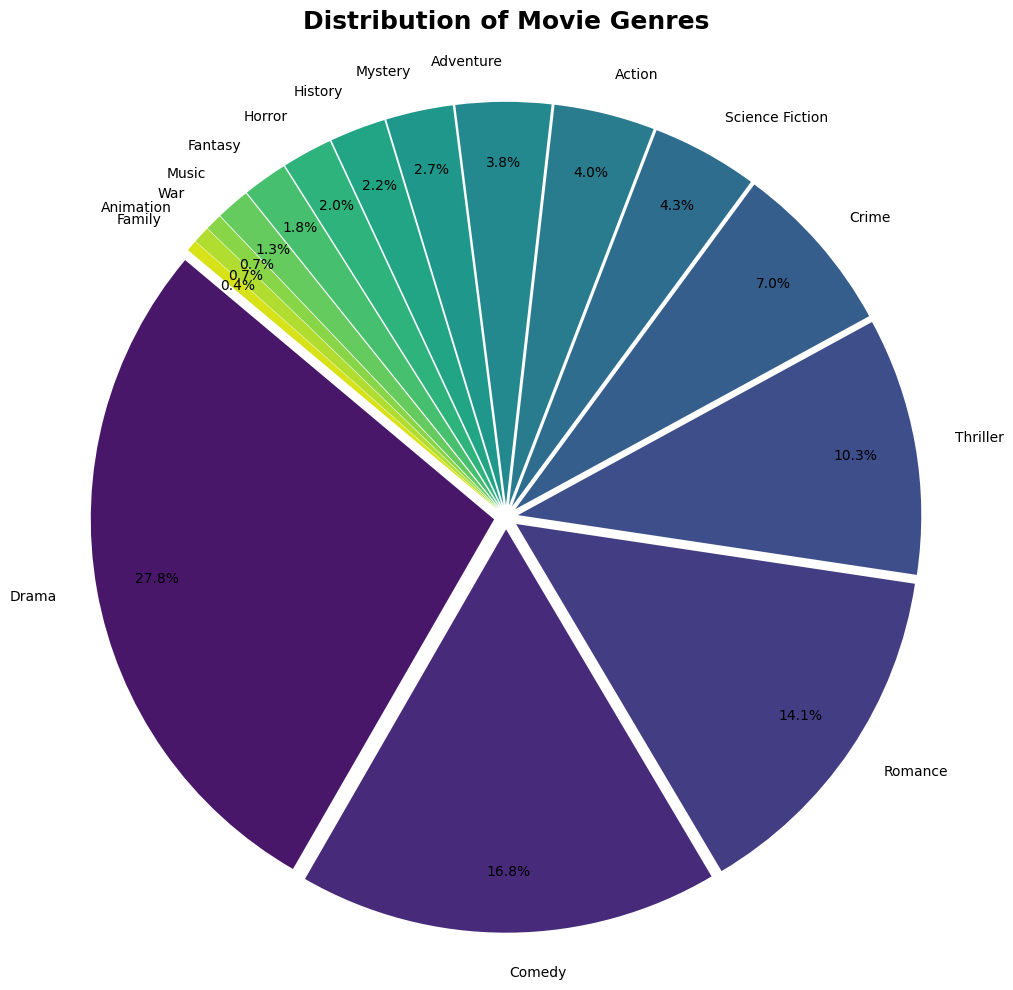

In [127]:
# Process genres (splitting and exploding multi-genre entries)
df_genres = df[df['Genre'].notna() & (df['Genre'] != 'Unknown')].copy()
genre_counts = df_genres['Genre'].str.split(', ').explode().value_counts()

# Create a Donut Chart
fig, ax = plt.subplots(figsize=(10, 10)) 

colors = sns.color_palette('viridis', len(genre_counts))

wedges, texts, autotexts = ax.pie(
    genre_counts, 
    labels=genre_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    pctdistance=0.85,
    explode=[0.03] * len(genre_counts)
)

# Add center circle for donut look (uncomment these if you want the donut hole!)
#centre_circle = plt.Circle((0,0), 0.70, fc='white')
#ax.add_artist(centre_circle)

plt.title('Distribution of Movie Genres', fontsize=18, fontweight='bold', pad=25)
plt.axis('equal') 
plt.tight_layout()
plt.show()

## 4.B Movie Genres (Treemap)
After making the initial pie chart, I realized that trying to have all 16 distinct genres has caused significant visual clutter. The slices were too thin and the labels were hard to read. For a better visual, I switched to a Treemap, which uses area size to make comparing amounts much easier.

Furthermore, I made the decision to filter the data to my Top 10 most-watched genres and group all remaining minor genres into a single category labeled "Others." I did this to respect the limits of preattentive perception. By filtering and aggregating the "long tail" of my data, I prevented cognitive overload, ensured the colors remained meaningful, and made the final visualization both truthful and easily readable. The Result demonstrated that, as expected, my most watched genere is Drama, followed by Comedy and Romance.

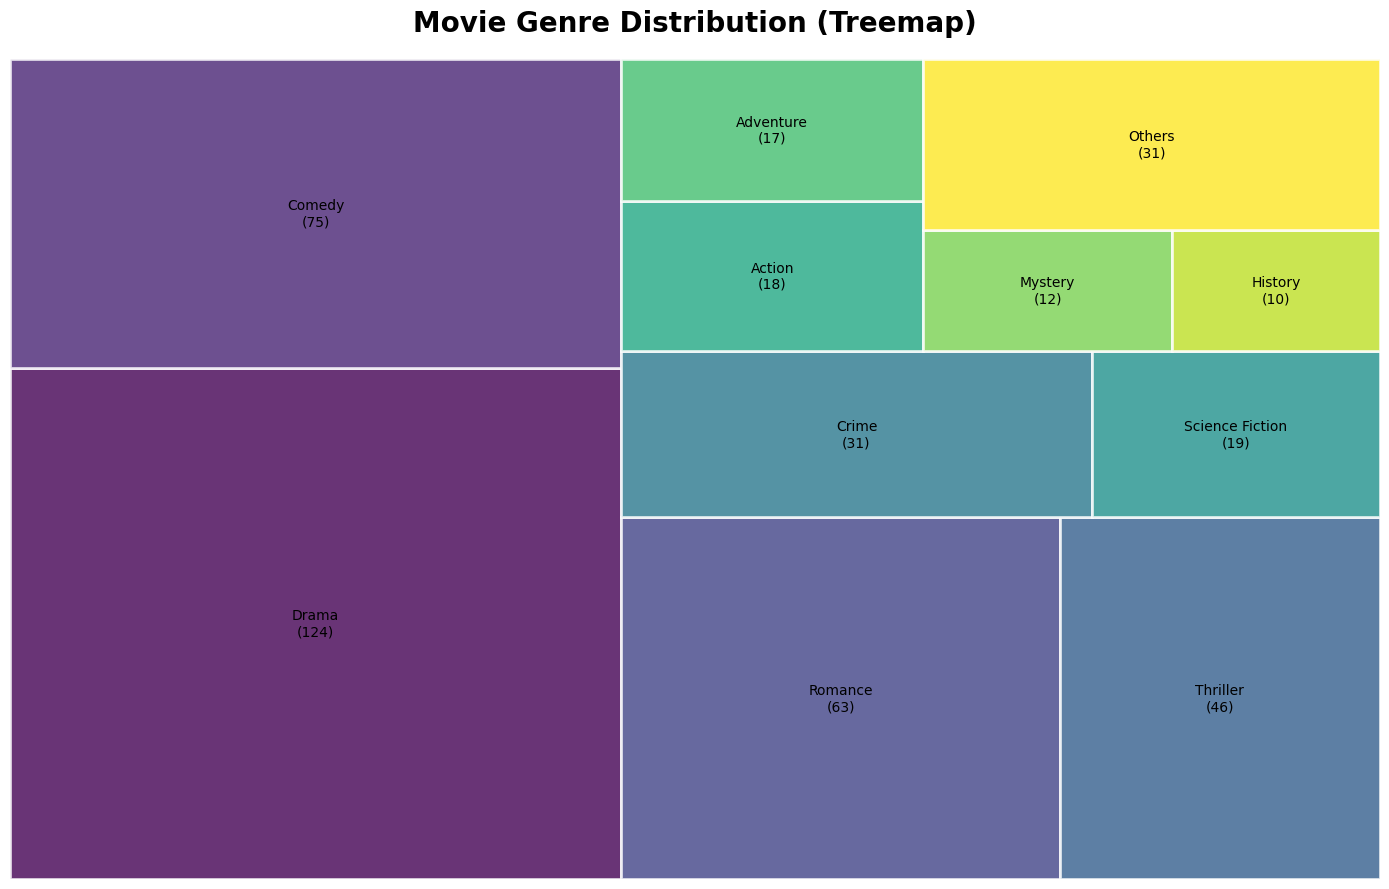

In [128]:

df_genres = df[df['Genre'].notna() & (df['Genre'] != 'Unknown')].copy()
genre_series = df_genres['Genre'].str.split(', ').explode()

#Get the full count
all_counts = genre_series.value_counts()

#Separate the Top 10 and the "Others"
top_10 = all_counts.head(10)
others_sum = all_counts.iloc[10:].sum()

#Combine them into one series
others_series = pd.Series({'Others': others_sum})
genre_counts = pd.concat([top_10, others_series])

labels = [f'{genre}\n({count})' for genre, count in zip(genre_counts.index, genre_counts.values)]
colors = plt.cm.viridis(np.linspace(0, 1, len(genre_counts)))

# Create the Treemap
plt.figure(figsize=(14, 9))
squarify.plot(
    sizes=genre_counts.values, 
    label=labels, 
    alpha=0.8, 
    color=colors,
    edgecolor="white",
    linewidth=2
)

plt.title('Movie Genre Distribution (Treemap)', fontsize=20, fontweight='bold', pad=20)
plt.axis('off') 

plt.tight_layout()
plt.show()


## 4.C Movie Genres (Interactive Treemap)
As I didn't want to permanently hide that data from the viewer. I decided to make the visualization interactive. By applying the Information Visualization principle of "Details on Demand," the chart remains clean and readable on the surface, but viewers can hover over the "Others" block to immediately see the exact breakdown and count of all the underlying sub-genres.

In [147]:
import pandas as pd
import plotly.graph_objects as go

df_genres = df[df['Genre'].notna() & (df['Genre'] != 'Unknown')].copy()
genre_series = df_genres['Genre'].str.split(', ').explode()

all_counts = genre_series.value_counts()

top_10 = all_counts.head(10)
others = all_counts.iloc[10:]
others_hover_details = "<br>".join([f"{genre}: {count}" for genre, count in others.items()])

labels = list(top_10.index) + ["Others"]
parents = [""] * len(labels) 
values = list(top_10.values) + [others.sum()]

hover_texts = [f"<b>{genre}</b><br>Total Watched: {count}" for genre, count in top_10.items()]
hover_texts.append(f"<b>Others (Total: {others.sum()})</b><br><br><i>Breakdown:</i><br>{others_hover_details}")

fig = go.Figure(go.Treemap(
    labels=labels,
    parents=parents,
    values=values,
    textinfo="label+value", 
    hoverinfo="text",        
    hovertext=hover_texts,
    
    textposition="middle center", 
    textfont=dict(size=14),       
    pathbar=dict(visible=False),  
    tiling=dict(packing="squarify", pad=2), 
    
    marker=dict(
        colors=values,
        colorscale='Viridis', 
        showscale=False,
        line=dict(color='white', width=0) 
    )
))

fig.update_layout(
    title=dict(text='Movie Genre Distribution (Interactive Treemap)', font=dict(size=20), x=0.5), 
    margin=dict(t=60, l=10, r=10, b=10), 
    paper_bgcolor='#f7f7f7',
    plot_bgcolor='#f7f7f7',
    
    width=1150,  
    height=600   
)

fig.show()


## 5. My Movie Ratings
Letterboxd uses a 0.5 to 5.0 star rating system. To visualize the distribution of my ratings, a Bar Chart was the perfect choice. Because movie ratings are ordinal data (they have a natural rank from lowest to highest score), bar charts allow the eye to easily compare the frequency of each category side-by-side.

My analysis demonstrates that I most frequently rate movies with 3 stars, with very few ratings of 4 stars or higher. Comparing the frequency of low ratings (0.5 to 1.0 stars) with high ratings, I seem to be quite selective when giving top scores, and tending to give average ratings like 2.5 or 3.0 stars.

/var/folders/4t/r2dg52q53m5_t64tj26d8ljm0000gn/T/ipykernel_38775/448557812.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


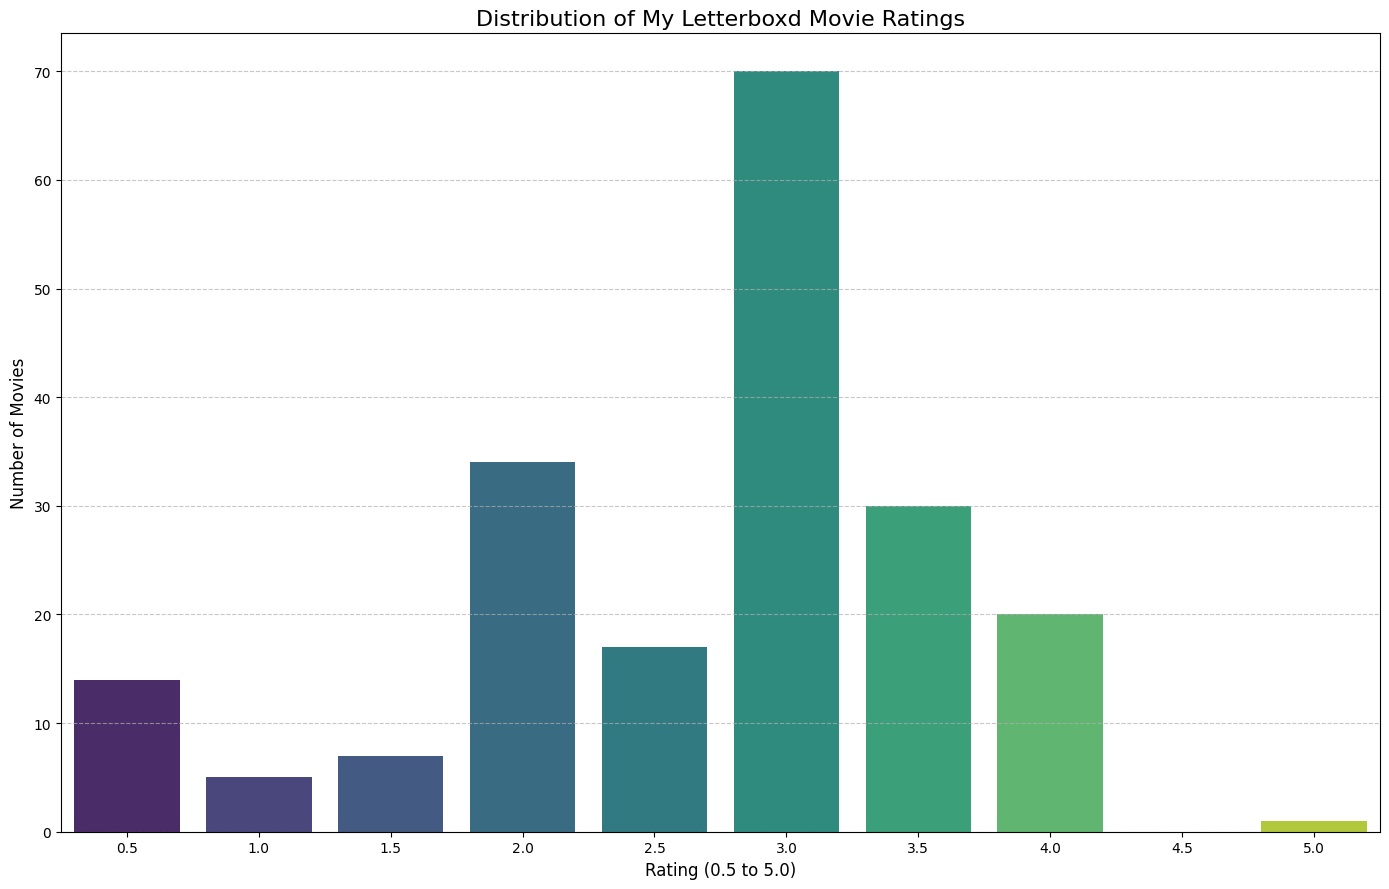

In [148]:
full_rating_order = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

plt.figure(figsize=(14, 9))

sns.countplot(
    data=df, 
    x='Rating', 
    palette='viridis', 
    order=full_rating_order 
)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.title('Distribution of My Letterboxd Movie Ratings', fontsize=16)
plt.xlabel('Rating (0.5 to 5.0)', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.tight_layout()
plt.show()

## 6.A Movies Watched Per Year
Tracking how my movie viewing volume changes over the years. As my diary data covers seven years (starting from 2020), this time frame is easily visualized and compared using a bar chart. While the results do not demonstrate a strict, linear trend (except an alternating pattern between odd and even years) but it does show an overall increase in viewing activity over time. Specifically the chart highlights that 2025 was the year in which I watched the highest number of movies.

/var/folders/4t/r2dg52q53m5_t64tj26d8ljm0000gn/T/ipykernel_38775/2852721029.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=movies_per_year.index.astype(int), y=movies_per_year.values, palette='magma')


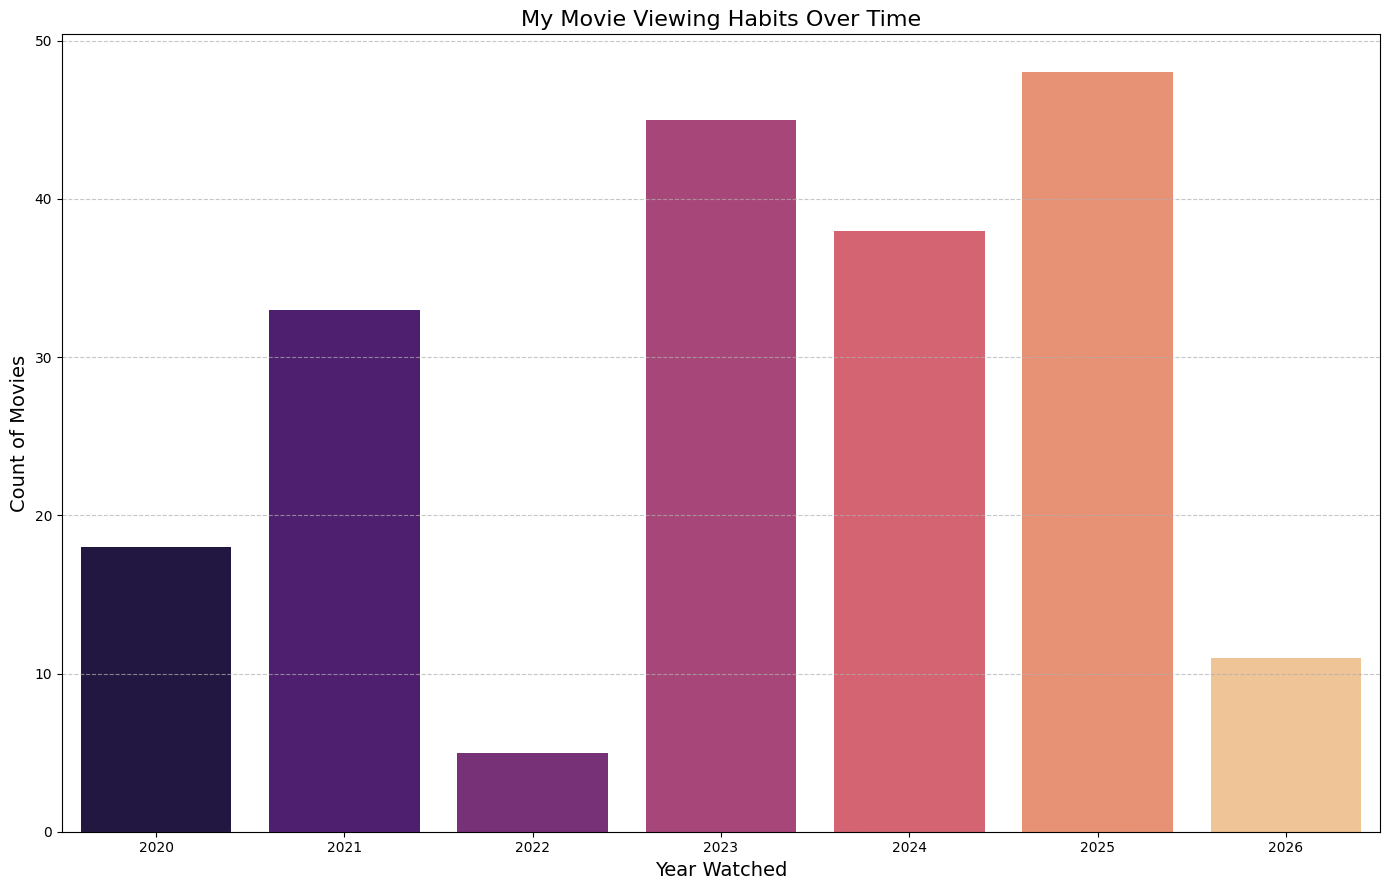

In [149]:
# Ensuring 'Watched Date' is a datetime object and extract the year
df['Watched Date'] = pd.to_datetime(df['Watched Date'])
df['Watched Year'] = df['Watched Date'].dt.year

plt.figure(figsize=(14, 9))
movies_per_year = df['Watched Year'].value_counts().sort_index()

sns.barplot(x=movies_per_year.index.astype(int), y=movies_per_year.values, palette='magma')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.title('My Movie Viewing Habits Over Time', fontsize=16)
plt.xlabel('Year Watched', fontsize=14)
plt.ylabel('Count of Movies', fontsize=14)
plt.tight_layout()
plt.show()


## 6.B Watching Habits by Month and Year
I wanted to see in which month I watch the most movies. First, I tried a grouped bar chart.


In [150]:
df = pd.read_csv('Dataset/main_enriched_full.csv')
df['Watched Date'] = pd.to_datetime(df['Watched Date'])

df['Month'] = df['Watched Date'].dt.month_name()
df['Year'] = df['Watched Date'].dt.year

monthly_habits = df.groupby(['Year', 'Month']).size().reset_index(name='Movie Count')

monthly_habits['Year'] = monthly_habits['Year'].astype(str)

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

fig = px.bar(
    monthly_habits, 
    x='Month', 
    y='Movie Count', 
    color='Year', 
    barmode='group',
    category_orders={'Month': month_order}, 
    template='plotly_white',                
    title='Movie Watching Habits: Seasonality by Month & Year',
    
    
    hover_data={'Month': False} 
)

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='Number of Movies Watched',
    title_font_size=20,
    legend_title='Year',
    margin=dict(t=80, b=50) 
)

fig.show()

## 6.C Watching Habits (Calendar Chart)
After reviewing the previous grouped bar chart, I decided a calendar heatmap was a much better design choice. While the bar chart allowed me to see the data, the inclusion of 7 years across 12 months created significant visual clutter, which made it difficult to identify the "big picture" or spot specific seasonal trends.

On the other hand, the heatmap offers a much cleaner layout that makes it easy to compare activity across every month and year simultaneously. By using darker colors to represent higher volumes, the busiest movie-watching months are easily discoverable. The result showes an interesting pattern: I tend to watch the most movies during February and March, reaching a peak of 12 movies in a single month. This is particular as there are no major holidays during that period. But on the other hand, I tend to watch the least movies during November, December, and January, even though those months are typically associated with holidays and free time.

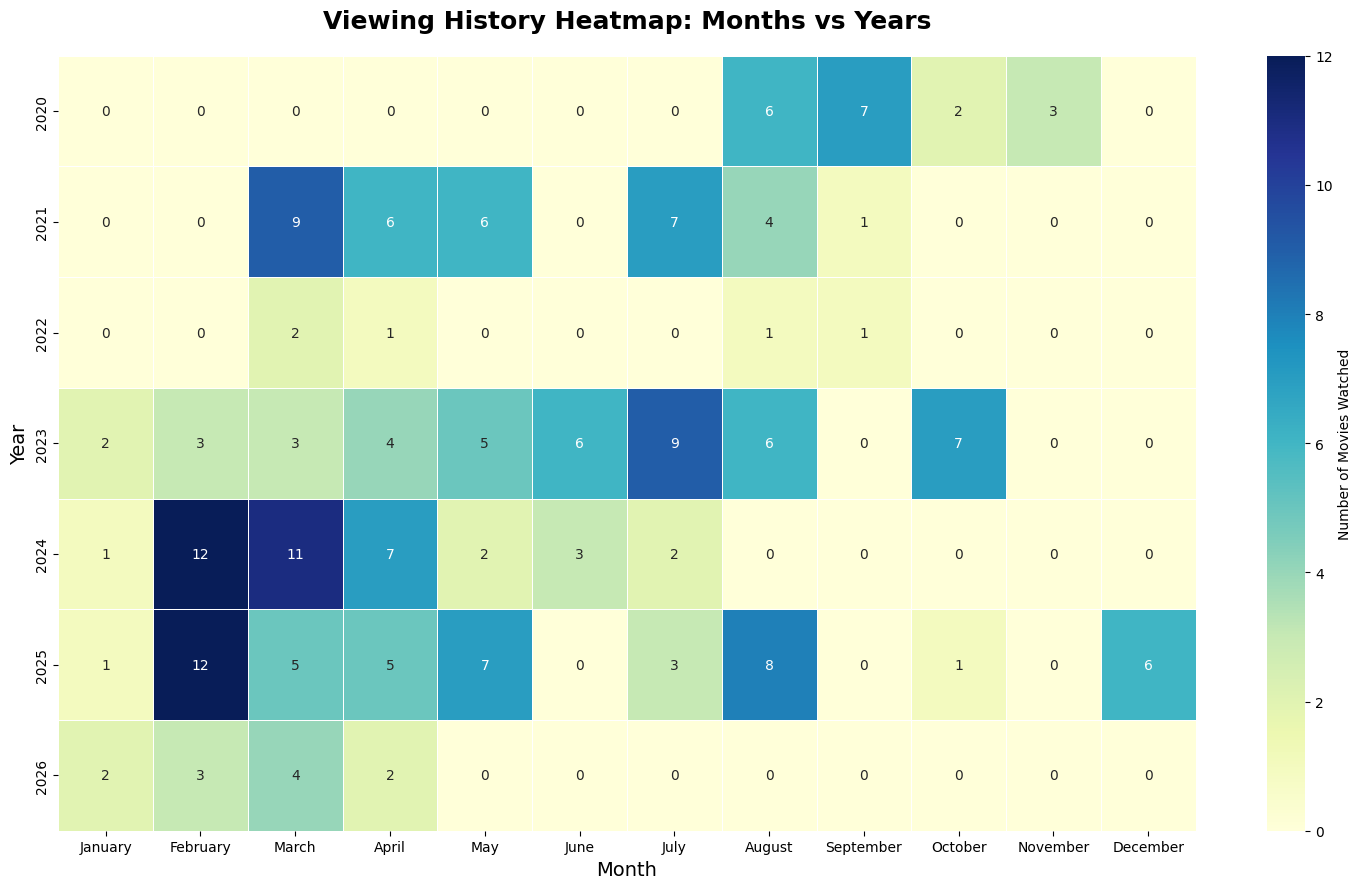

In [151]:

df['Watched Date'] = pd.to_datetime(df['Watched Date'])

# Extract Year and Month Name
df['Year'] = df['Watched Date'].dt.year
df['Month'] = df['Watched Date'].dt.month_name()

# Create a pivot table: Rows = Years, Columns = Months
pivot_table = df.groupby(['Year', 'Month']).size().unstack(fill_value=0)

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
# Filter the list to only include months that actually exist in dataset
available_months = [m for m in month_order if m in pivot_table.columns]
pivot_table = pivot_table[available_months]

plt.figure(figsize=(15, 9))
sns.heatmap(
    pivot_table, 
    annot=True,      
    fmt="d",         
    cmap="YlGnBu",   
    linewidths=.5,   
    cbar_kws={'label': 'Number of Movies Watched'}
)
plt.title('Viewing History Heatmap: Months vs Years', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Year', fontsize=14)
plt.tight_layout()
plt.show()


## 7. When Were These Movies Released?
This chart shows the original release years of the movies I have watched. I used a histogram combined with a Kernel Density Estimate (KDE) to highlight the distribution of the data and reveal the overall trend, showing whether I prefer older classics or brand-new releases. The results indicate that I have a preference for recently released movies.

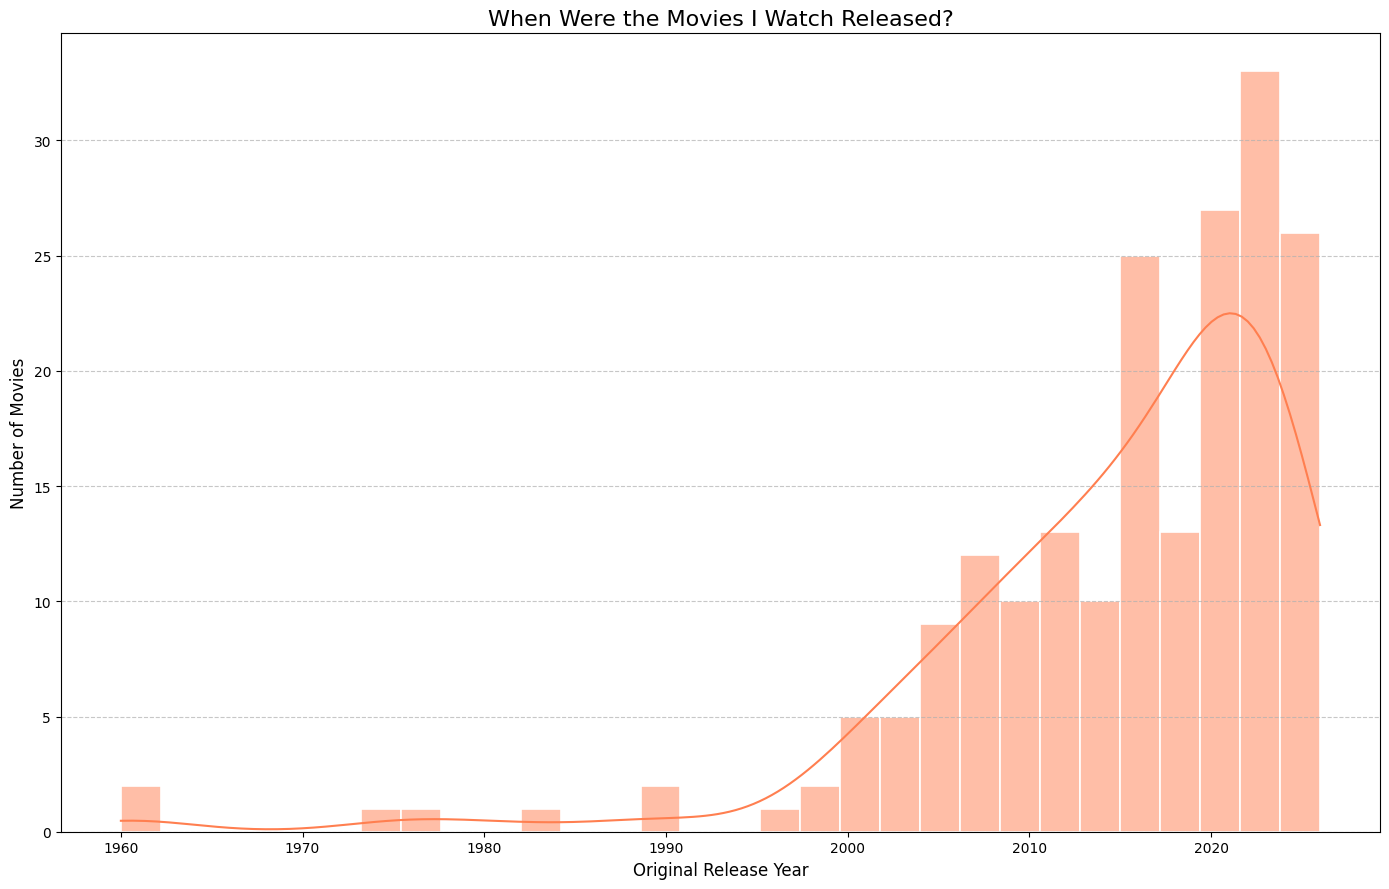

In [152]:
df = pd.read_csv('Dataset/main_enriched_full.csv')

plt.figure(figsize=(14, 9))
# Using a histogram with a Kernel Density Estimate to show the trend
sns.histplot(data=df, x='Year', bins=30, color='coral', kde=True, edgecolor='white', linewidth=1.2)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.title('When Were the Movies I Watch Released?', fontsize=16)
plt.xlabel('Original Release Year', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Where Do My Movies Come From?
I was curious about my preferences about the origin country of each movie. Using the Country data that I already fetched from the TMDB API during the data preparation phase (Section 2), I can now map out the global footprint of my movie-watching habits.

As some movies are the production of multiple countries, I decided to include all secondary production countries rather than just the primary one. I wanted to remain truthful to the data and be able  to spot potential anomalies or patterns, which I might have otherwise missed. The results indicate that the vast majority of movies I watch are from the United States. While my viewing habits cover Asia, Australia, the Americas, and Europe, I have watched almost no movies produced in Africa. Also there are many countries from which I have watched only one movie, which was quite unexpected—such as the UAE, Jordan, and others(the long tail).

In [153]:

df = pd.read_csv('Dataset/main_enriched_full.csv')

# Country is missing or 'Unknown'
df_countries = df[df['Country'].notna() & (df['Country'] != 'Unknown') & (df['Country'] != 'Error')].copy()

# split multi countries by the comma and create a separate row for each country
df_countries['Country'] = df_countries['Country'].str.split(', ')
df_exploded = df_countries.explode('Country')

# Count 
country_counts = df_exploded['Country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Movie Count']


fig = px.choropleth(
    data_frame=country_counts,
    locations='Country',
    locationmode='country names', 
    color='Movie Count',
    color_continuous_scale='Viridis', 
    title='Global Footprint of My Movie Viewing Habits',
    labels={'Movie Count': 'Number of Movies'}
)

fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='equirectangular'
    ),
    title_font_size=18,
    title_x=0.5, 

    width=1150,  
    height=600 
)

fig.show()


/var/folders/4t/r2dg52q53m5_t64tj26d8ljm0000gn/T/ipykernel_38775/2255614071.py:15: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


## 9.A Reviews vs. Ratings

Analyzing the relationship between the number of written reviews and the star rating level to see if a pattern exists. The results shows that I leave the highest number of reviews for movies rated in the "average to high" range (3.0, 3.5 stars). Interestingly, I write very few reviews for highly rated movies. On the other hand, there is a higher volume of reviews for 0.5-star ratings compared to 1.0 or 1.5-star ratings, which indicates an anomaly, that I am more likely to leave a review when I strongly dislike a film than when I am a bit dissatisfied with it.
I shows that my motivation to write a review is driven by strong emotions, either extreme disappointment or a desire to process average experiences, rather than a linear relationship with the rating. 

/var/folders/4t/r2dg52q53m5_t64tj26d8ljm0000gn/T/ipykernel_38775/2082905857.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


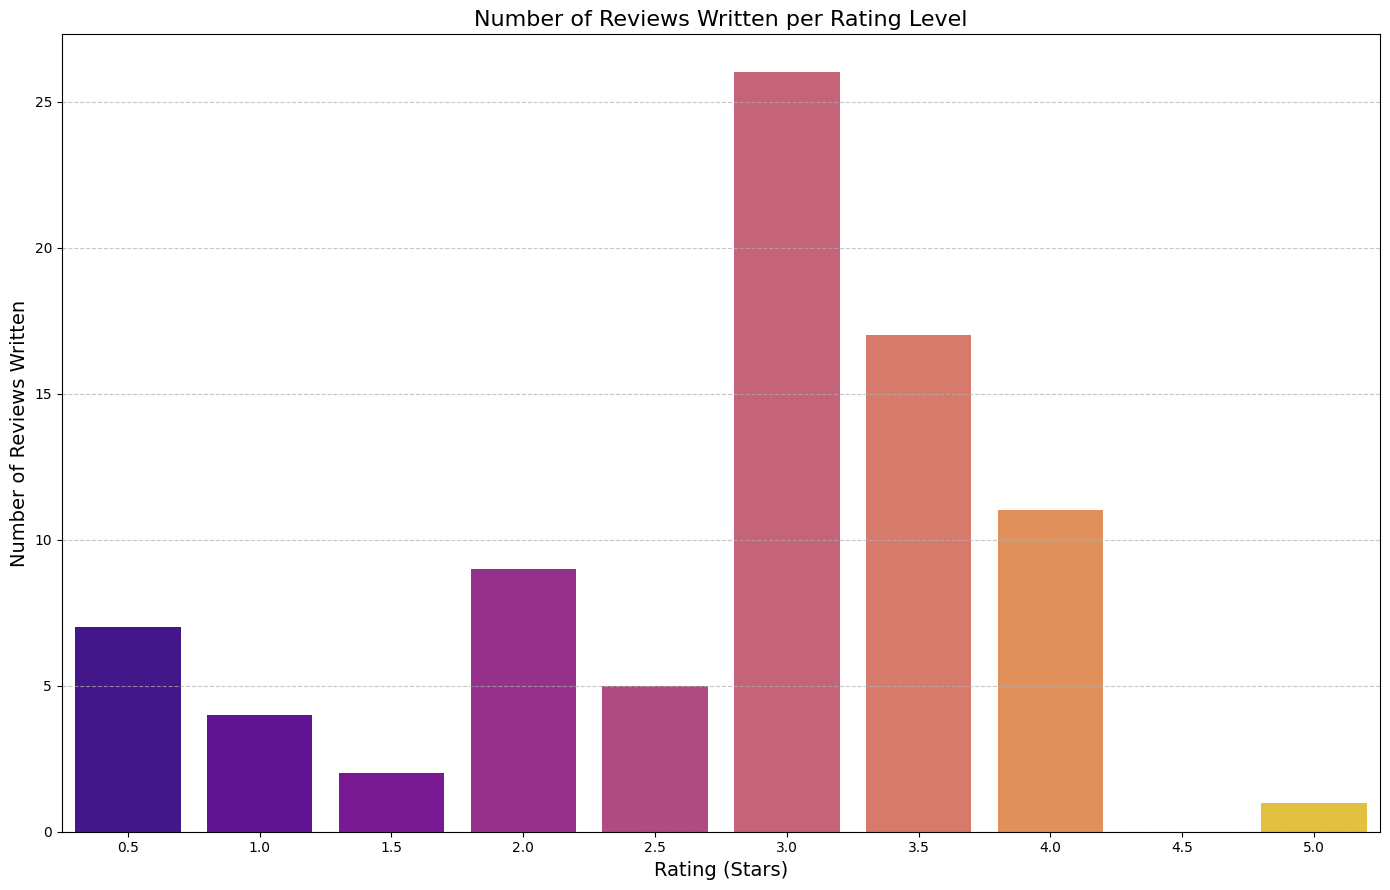

Total movies with reviews: 82


In [113]:
df_with_reviews = df[df['Review'].notna() & (df['Review'].str.strip() != '')].copy()

full_rating_order = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]


plt.figure(figsize=(14, 9))


sns.countplot(
    data=df_with_reviews, 
    x='Rating', 
    palette='plasma', 
    order=full_rating_order
)

plt.title('Number of Reviews Written per Rating Level', fontsize=16)
plt.xlabel('Rating (Stars)', fontsize=14)
plt.ylabel('Number of Reviews Written', fontsize=14)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Total movies with reviews: {len(df_with_reviews)}")

## 9.B  Rating Trends Over Time
After looking at my ratings overall, I wanted to see how my scoring habits have changed over the years. Are my standards getting higher, or am I becoming more generous?

To answer this, I calculated my average rating for each year and visualized it on a line chart. The result demonstrated no perticular changes in the rate of the watched movies over the year.

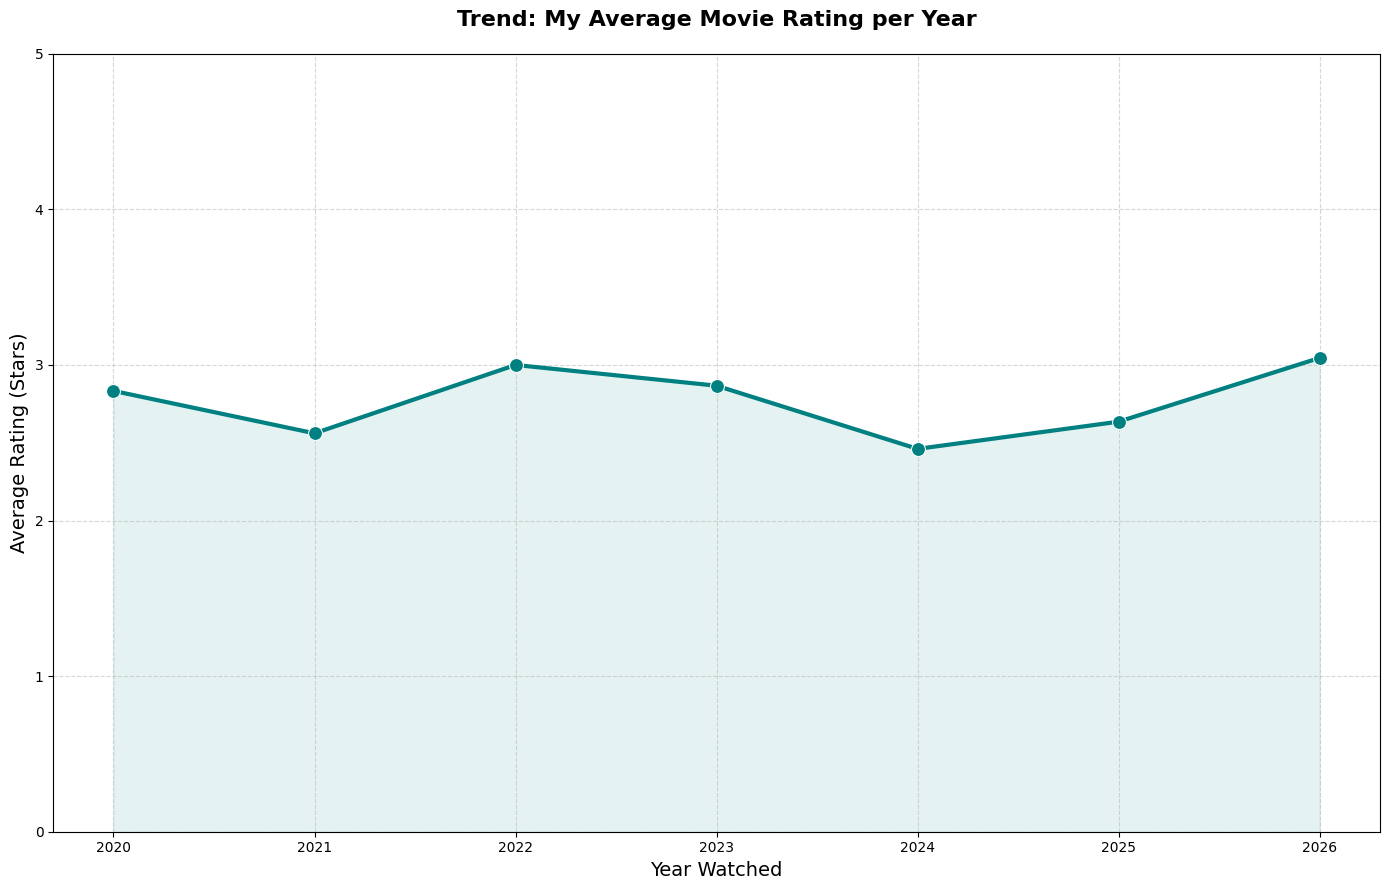

In [154]:

df = pd.read_csv('Dataset/main_enriched_full.csv')
df['Watched Date'] = pd.to_datetime(df['Watched Date'])
df['Watched Year'] = df['Watched Date'].dt.year

# the average rating per year
avg_rating_year = df.groupby('Watched Year')['Rating'].mean().reset_index()

plt.figure(figsize=(14, 9))
sns.lineplot(
    data=avg_rating_year, 
    x='Watched Year', 
    y='Rating', 
    marker='o', 
    color='teal', 
    linewidth=3, 
    markersize=10
)

plt.fill_between(avg_rating_year['Watched Year'], avg_rating_year['Rating'], color='teal', alpha=0.1)

plt.title('Trend: My Average Movie Rating per Year', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year Watched', fontsize=14)
plt.ylabel('Average Rating (Stars)', fontsize=14)

plt.xticks(avg_rating_year['Watched Year'].astype(int))

plt.ylim(0, 5.0)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 10.A Do I write longer reviews for movies I like or for the ones I hate?
I wanted to see for which rate of movies I tend to write longer reviews. 

/var/folders/4t/r2dg52q53m5_t64tj26d8ljm0000gn/T/ipykernel_38775/55097325.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


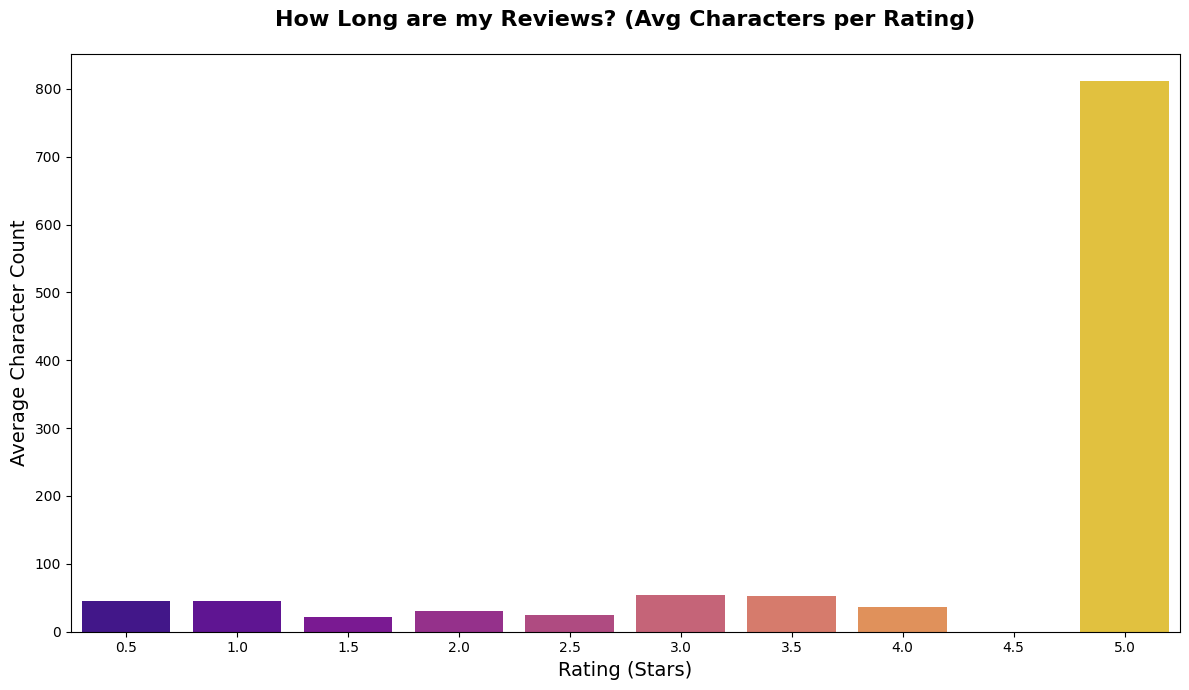


--- Average Review Length per Rating ---
Rating
0.5     44.9
1.0     45.2
1.5     22.0
2.0     31.2
2.5     25.2
3.0     54.6
3.5     51.9
4.0     35.7
5.0    811.0
Name: Review Length, dtype: float64


In [157]:

df = pd.read_csv('Dataset/main_enriched_full.csv')

df_reviews = df[df['Review'].notna() & (df['Review'].str.strip() != '')].copy()

#Calculate the character count for each review
df_reviews['Review Length'] = df_reviews['Review'].str.len()

rating_order = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

plt.figure(figsize=(12, 7))

sns.barplot(
    data=df_reviews, 
    x='Rating', 
    y='Review Length', 
    order=rating_order, 
    palette='plasma',
    estimator='mean', 
    errorbar=None      
)

plt.title('How Long are my Reviews? (Avg Characters per Rating)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Rating (Stars)', fontsize=14)
plt.ylabel('Average Character Count', fontsize=14)

plt.tight_layout()
plt.show()

print("\n--- Average Review Length per Rating ---")
print(df_reviews.groupby('Rating')['Review Length'].mean().round(1))

# 10.B Finding out and Removing the Outlier
By analysing the previous chart, I noticed one significant outlier which was a review for the movie "Hello FatherDog." This was a long, quoted review that I had copy pasted, and wasn't originally mine. Given that I was intrested to find a pattern in my own written reviews, I decided to delete this outlier from my data. 
By filtering out this anomaly, the resulting chart now provides a truthful representation of my personal writing patterns, making the actual distribution of my review lengths, by average character count,visible and readable.

Successfully created Dataset/main_cleaned.csv (outlier removed).


/var/folders/4t/r2dg52q53m5_t64tj26d8ljm0000gn/T/ipykernel_38775/2683942473.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


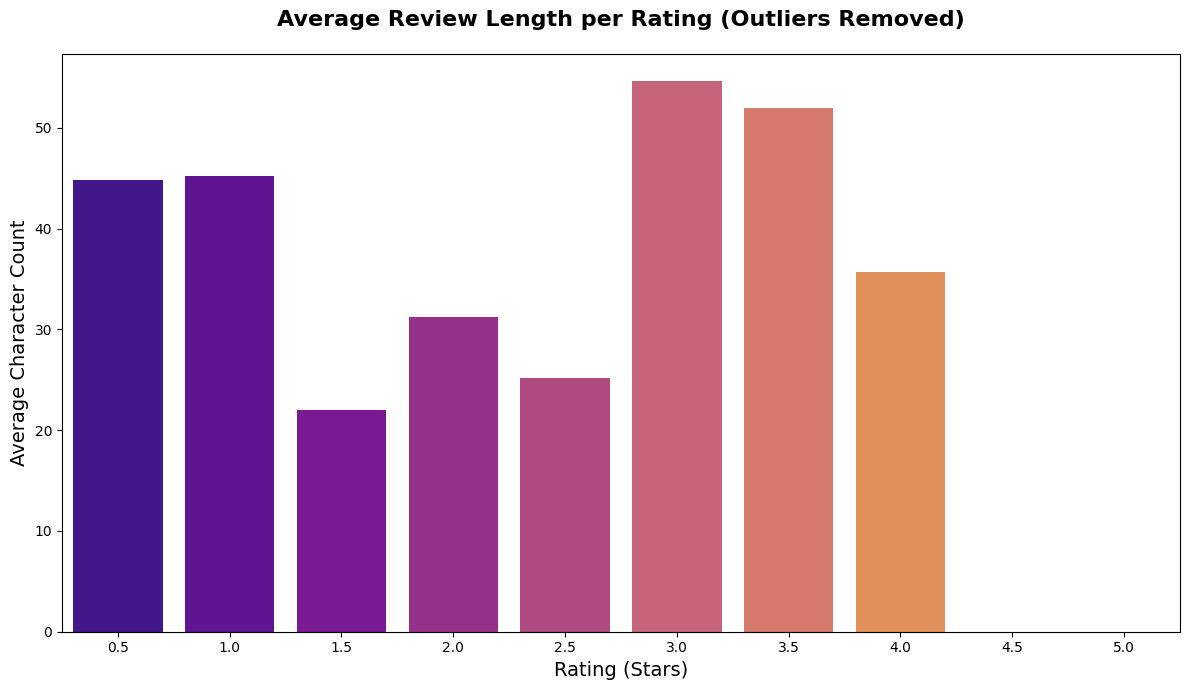

In [158]:

df = pd.read_csv('Dataset/main_enriched_full.csv')

#Remove the specific "Hello FatherDog" entry
df_cleaned = df[df['Name'] != 'Hello FatherDog'].copy()
df_cleaned.to_csv('Dataset/main_cleaned.csv', index=False)
print("Successfully created Dataset/main_cleaned.csv (outlier removed).")

df_reviews = df_cleaned[df_cleaned['Review'].notna() & (df_cleaned['Review'].str.strip() != '')].copy()

df_reviews['Review Length'] = df_reviews['Review'].str.len()

rating_order = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

plt.figure(figsize=(12, 7))
sns.barplot(
    data=df_reviews, 
    x='Rating', 
    y='Review Length',
    order=rating_order, 
    palette='plasma',
    estimator='mean',
    errorbar=None
)

plt.title('Average Review Length per Rating (Outliers Removed)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Rating (Stars)', fontsize=14)
plt.ylabel('Average Character Count', fontsize=14)

plt.tight_layout()
plt.show()

## 10. C Review Habits: Average Length vs. Total Volume
I tried to first visualize both average length of characters for each review per rate, with a bar chart, and also the number of left reviews by rate, with different scales, to see if I can combine them together for further analysis.


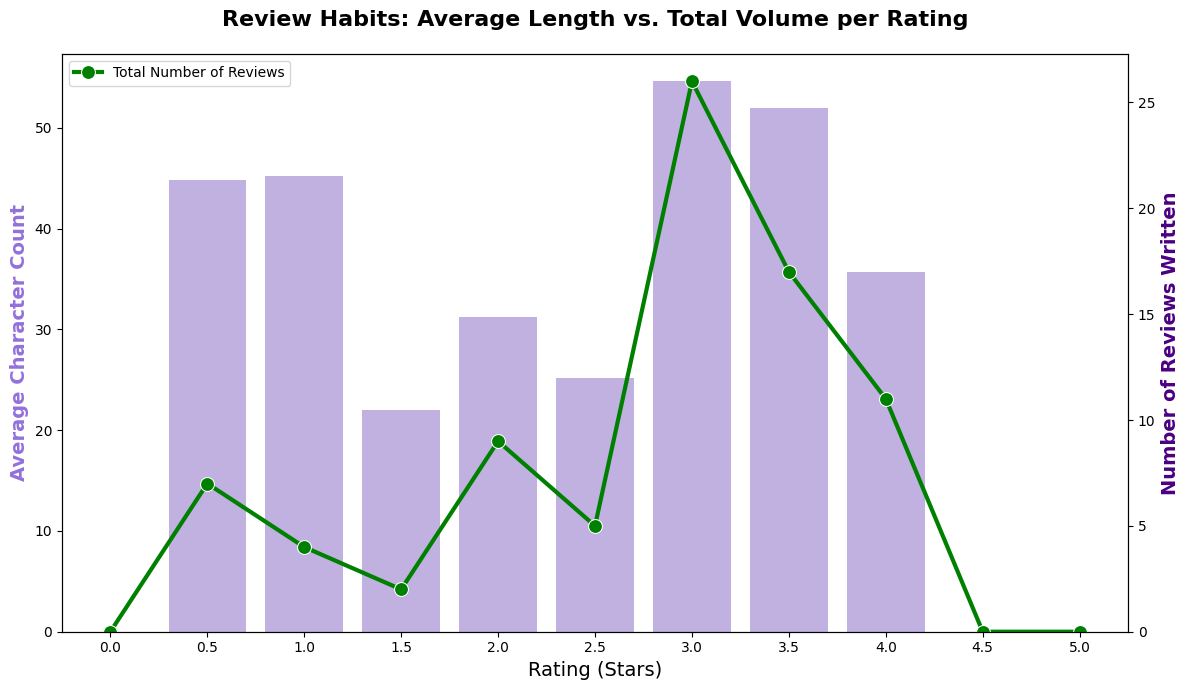

Analysis based on 81 written reviews.


In [159]:

df = pd.read_csv('Dataset/main_enriched_full.csv')

df_cleaned = df[df['Name'] != 'Hello FatherDog'].copy()
df_reviews = df_cleaned[df_cleaned['Review'].notna() & (df_cleaned['Review'].str.strip() != '')].copy()
df_reviews['Review Length'] = df_reviews['Review'].str.len()

grouped_data = df_reviews.groupby('Rating').agg(
    Avg_Length=('Review Length', 'mean'),
    Review_Count=('Review Length', 'count')
).reset_index()

rating_scale = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
all_ratings = pd.DataFrame({'Rating': rating_scale})

merged_data = pd.merge(all_ratings, grouped_data, on='Rating', how='left').fillna(0)

fig, ax1 = plt.subplots(figsize=(12, 7))

# THE BARS (Average Length on the Left Y-Axis)
sns.barplot(
    data=df_reviews, 
    x='Rating', 
    y='Review Length', 
    order=rating_scale, 
    color='mediumpurple', 
    alpha=0.6, 
    errorbar=None,
    estimator='mean',
    ax=ax1
)
ax1.set_ylabel('Average Character Count', fontsize=14, color='mediumpurple', fontweight='bold')
ax1.set_xlabel('Rating (Stars)', fontsize=14)
ax1.set_ylim(bottom=0)

#THE LINE (Review Count on the Right Y-Axis)
ax2 = ax1.twinx() 

sns.lineplot(
    data=merged_data, 
    x=merged_data.index, 
    y='Review_Count', 
    color='green', 
    marker='o', 
    linewidth=3,
    markersize=10,
    label='Total Number of Reviews',
    ax=ax2
)
ax2.set_ylabel('Number of Reviews Written', fontsize=14, color='indigo', fontweight='bold')
ax2.set_ylim(bottom=0)

plt.title('Review Habits: Average Length vs. Total Volume per Rating', fontsize=16, fontweight='bold', pad=20)

lines, labels = ax2.get_legend_handles_labels()
ax2.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()

print(f"Analysis based on {len(df_reviews)} written reviews.")

## 10.D Review Habits: Length vs. Volume
By visualizing both the total number of reviews and the average character count on the same scale, I was able to check the relationship between rating, frequency, and effort in a way.

The results demonstrated a pattern that I write the highest volume of reviews for movies rated in the average range (3.0–3.5 stars). On the other hand, I write very few reviews for highly-rated movies (4.5–5.0 stars). An  anomaly appears at the bottom of the scale, which is that I write significantly more reviews for 0.5-star movies than for those rated 1.0 or 1.5 stars.

This shows that my motivation to write a review is driven by strong emotions, either a disappointment or a desire to process "average to high" experiences, rather than a linear relationship with the rating. Furthermore, the review lengths revealed that I tend to write longer reviews when I feel the need to justify why a movie was "not quite perfect" (missing out on a 4- or 5-star rating) or to explain exactly why a film was a total failure (the 0.5-star reviews).

In [165]:

grouped_data = df_reviews.groupby('Rating').agg(
    Avg_Length=('Review Length', 'mean'),
    Review_Count=('Review Length', 'count')
).reset_index()

rating_scale = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
all_ratings = pd.DataFrame({'Rating': rating_scale})
merged_data = pd.merge(all_ratings, grouped_data, on='Rating', how='left').fillna(0)

fig = go.Figure()

# THE BARS 
fig.add_trace(go.Bar(
    x=merged_data['Rating'],
    y=merged_data['Avg_Length'],
    name='Average Character Count',
    marker_color='#af8dc3', 
    opacity=0.8,            
    hovertemplate='Rating: %{x} Stars<br>Avg Length: %{y:.1f} chars<extra></extra>'
))

# THE LINE 
fig.add_trace(go.Scatter(
    x=merged_data['Rating'],
    y=merged_data['Review_Count'],
    name='Total Number of Reviews',
    mode='lines+markers',
    line=dict(color='#7fbf7b', width=4), 
    marker=dict(size=10, color='#7fbf7b', line=dict(width=1, color='white')),
    hovertemplate='Rating: %{x} Stars<br>Total Reviews: %{y}<extra></extra>'
))

fig.update_layout(
    plot_bgcolor='#f7f7f7', 
    paper_bgcolor='white',
    
    autosize=True, 
    margin=dict(l=40, r=40, t=80, b=40), 
    
    title=dict(
        text='Review Habits: Average Length vs. Total Volume per Rating',
        font=dict(size=20, color='black'),
        x=0.5 # Center the title
    ),
    xaxis=dict(
        title='Rating (Stars)',
        title_font=dict(size=14),
        tickmode='array',
        tickvals=rating_scale 
    ),
    yaxis=dict(
        title='Count (Characters & Number of Reviews)',
        title_font=dict(size=14),
        rangemode='tozero' 
    ),
    legend=dict(
        x=0.01,
        y=0.99,
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='lightgray',
        borderwidth=1
    ),
    hovermode='x unified' 
)

fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')

fig.show()

fig.write_html(
    'My Review Habits.html', 
    include_plotlyjs='cdn', 
    full_html=True,         
    default_width='100%',   
    default_height='100%'   
)


## 11. Review and Conclusion

For this project, I analyzed my personal data from Letterboxd, which ia a social platform for film lovers and I started using it from 2020 actively. The platform allows users to log the movies they watch in a "diary," rate them on a 0.5 to 5.0 star scale, and write written reviews. My raw data export initially consisted of two separate, basic CSV files. The first was my diary log, which tracked basic attributes (Watched Date, Name, Year, and Rating). The second was a reviews file, which contained similar metadata but included the actual Review text.
To create a comprehensive dataset, I first merged these two files based on their common columns. However, to enable a much deeper visual analysis of my habits, I needed more context. I used the TMDB API to enrich the dataset, fetching missing metadata for every single movie and adding two crucial new columns to my final CSV: Genre and Country.
When I exported my data, I realized I did not remember much about the reviews I had written. I have a personal theory about my reviewing habits: I only leave a review when a movie provokes a strong reaction. Also on the other hand, when I truly love a movie and give it a high rating, the score speaks for itself and there is no need to a written review. I wanted to use Data Sense-Making to test this theory and uncover the hidden patterns in my viewing and reviewing habits.

I started by exploring the broader context of my data mapping out my most-watched genres and seasonal viewing habits. Through an iterative design process and by analysing the results through trials, I learned to avoid visual clutter, and trying for cleaner visuals like Treemaps and Calendar Heatmaps to make my viewing patterns easily readable.

When I finally moved to analyzing my reviews, I was curious about the relationship between the star rating, the total number of reviews, and the character count. During my first visualization attempt, I noticed a massive outlier, which was a quoted review for the movie "Hello FatherDog" that I hadn't originally written and it was basically a copy-pasted review. As I wanted my analysis to be only a representation of my own writing, I made the decision to clean the data and eliminate this anomaly.

By putting both "average character count" and "total number of reviews" on the same scale, I created a dual-axis chart. As a design decision, I chose a Purple-Green contrast palette (#af8dc3 and #7fbf7b). Because these variables measure two entirely different things, using distinct, contrasting hues ensures they remain visually separated. Furthermore, Purple/Green is a colorblind-safe combination, ensuring the visualization remains accessible while allowing the line trend to preattentively "pop out" against the softer bars.

The final chart proved partially my initial theory and gave me more intresting details. It revealed that I write the highest volume of reviews for movies in the "average to high" range (3.0–3.5 stars), while I write very few for highly-rated movies (4.5–5.0 stars). Furthermore, an anomaly appeared at the bottom of the scale that I write significantly more reviews for 0.5-star movies than for those rated 1.0 or 1.5 stars.

This indicates that my motivation to write a review is driven by strong emotions, which is either deep disappointment or a desire to process "average to high" experiences, rather than a linear relationship with the rating. The review lengths also showed intresting facts to make me realize that I write longer texts when I need to justify why a movie was "not quite perfect" (missing out on a 4- or 5-star rating) or to explain exactly why a film was a total failure (the 0.5-star reviews).

While this visualization successfully revealed my reviewing patterns, the dataset has limitations. It lacks the contextual data needed to connect my movie-watching habits with my state of mind or busy life periods (such as immigrating, studying, or working full-time). Additionally, I cannot account for external factors that control my review writing, such as finishing a movie late at night and simply forgetting to log a review. Despite these limitations, this project successfully transformed raw diary entries into a clear reflection of my personal behavior.